# NIFTY-Sentinel: cleaning and EDA
Run after `01_data_collection.ipynb`. Replace exploratory fields with official data before final analysis.

In [1]:
import os
os.chdir(r'C:\Users\deepa\Documents\ChatGPT\ML 2 porject')
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from src.config import FIGURES_DIR, PROCESSED_DATA_DIR, ensure_project_dirs
from src.features import future_stress_label, log_returns, market_features

ensure_project_dirs()
canonical_path = PROCESSED_DATA_DIR / 'canonical_market_data.csv'
fallback_path = PROCESSED_DATA_DIR / 'master_market_data.csv'
raw_fallback_path = RAW_DATA_DIR / 'exploratory_market_prices.csv' if 'RAW_DATA_DIR' in globals() else None
if canonical_path.exists():
    prices = pd.read_csv(canonical_path, parse_dates=['date']).set_index('date').sort_index()
elif fallback_path.exists():
    prices = pd.read_csv(fallback_path, parse_dates=['date']).set_index('date').sort_index()
elif raw_fallback_path is not None and raw_fallback_path.exists():
    prices = pd.read_csv(raw_fallback_path, parse_dates=['date']).set_index('date').sort_index()
else:
    raise FileNotFoundError('No canonical, master, or exploratory market-data file is available.')
# Keep the NIFTY trading calendar. Forward-fill only short non-trading-calendar gaps and never fill NIFTY closes.
prices = prices.loc[prices['nifty_close'].notna()].ffill(limit=3)
prices.to_csv(PROCESSED_DATA_DIR / 'master_market_data.csv')
prices.tail()

,brent,gold,india_vix,nifty_close,sp500,us_vix,usd_inr
date,,,,,,,
2026-09-11,104.610001,4408.899902,12.29,23398.099609,7656.979980,15.840000,95.694504
2026-09-15,108.750000,4332.799805,13.43,23118.599609,7585.729980,17.200001,95.835403
2026-09-16,105.830002,4387.500000,13.17,23217.599609,7551.810059,17.709999,95.992699
2026-09-17,104.820000,4399.700195,12.29,23270.599609,7637.759766,15.440000,96.132301
2026-09-18,99.290001,4424.899902,11.39,23346.400391,7650.500000,14.810000,95.799202


In [2]:
features = market_features(prices['nifty_close'])
features['india_vix_change'] = prices['india_vix'].pct_change()
features['usd_inr_return'] = prices['usd_inr'].pct_change()
features['gold_return'] = prices['gold'].pct_change()
if 'nifty_close_volume' in prices.columns:
    volume = prices['nifty_close_volume']
    features['abnormal_volume_20d'] = (volume - volume.rolling(20).mean()) / volume.rolling(20).std()
features['stress_next_10d'] = future_stress_label(prices['nifty_close'], horizon=10)
features.to_csv(PROCESSED_DATA_DIR / 'market_state_features.csv')
features.describe().T

,count,mean,std,min,25%,50%,75%,max
nifty_close,4105.0,12372.237925,6599.31107,4544.200195,6493.100098,10388.75,17576.849609,26328.550781
nifty_log_return,4104.0,0.000364,0.010393,-0.139038,-0.004814,0.000546,0.006022,0.084003
volatility_5d,4100.0,0.137192,0.091258,0.015586,0.082337,0.117807,0.167083,1.335954
momentum_5d,4100.0,0.002087,0.02324,-0.190239,-0.010892,0.003115,0.016108,0.107031
drawdown_5d,4105.0,-0.00934,0.013205,-0.169936,-0.014285,-0.004391,0.0,0.0
volatility_20d,4085.0,0.147364,0.07414,0.050175,0.102942,0.133144,0.171933,0.904851
momentum_20d,4085.0,0.008643,0.046491,-0.370057,-0.017256,0.009877,0.037509,0.202904
drawdown_20d,4105.0,-0.022531,0.02906,-0.356666,-0.032845,-0.013583,-0.002092,0.0
volatility_60d,4045.0,0.151943,0.065499,0.072919,0.112721,0.140745,0.177702,0.586345
momentum_60d,4045.0,0.026376,0.076863,-0.372431,-0.020847,0.030916,0.075592,0.375907


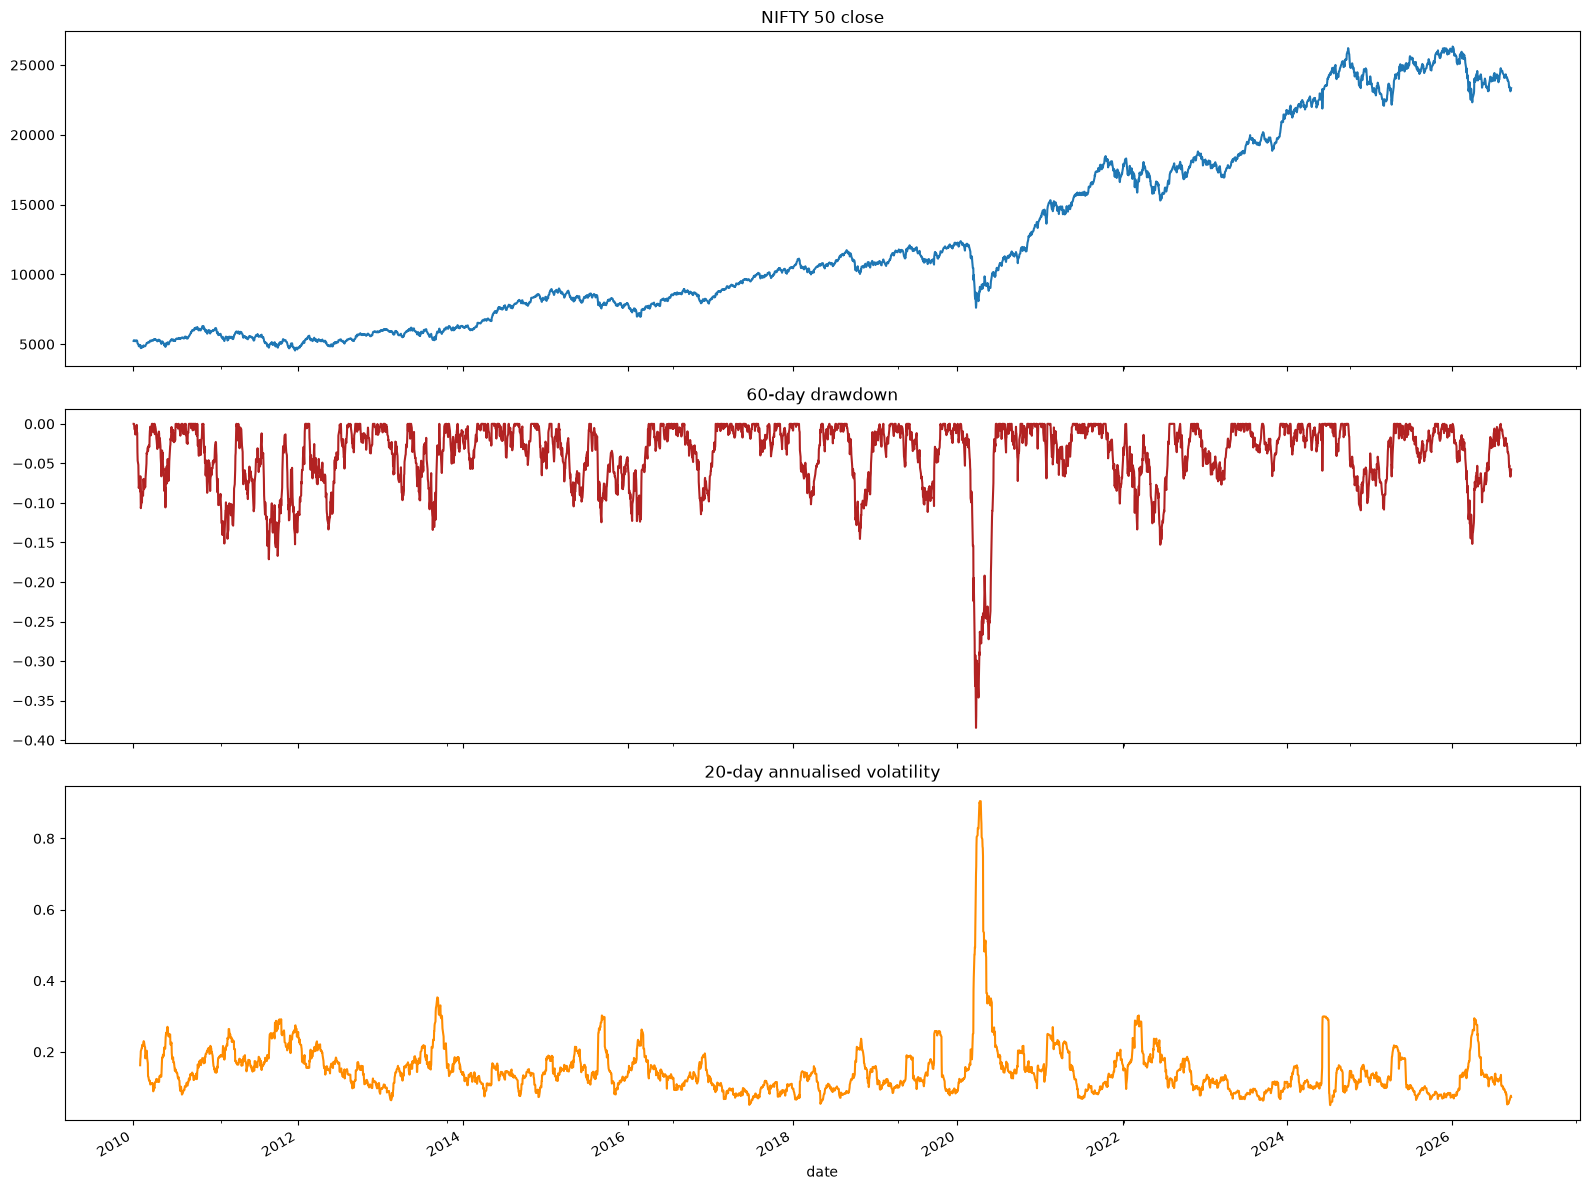

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
features['nifty_close'].plot(ax=axes[0], title='NIFTY 50 close')
features['drawdown_60d'].plot(ax=axes[1], color='firebrick', title='60-day drawdown')
features['volatility_20d'].plot(ax=axes[2], color='darkorange', title='20-day annualised volatility')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eda_nifty_drawdown_volatility.png', dpi=180, bbox_inches='tight')
plt.show()

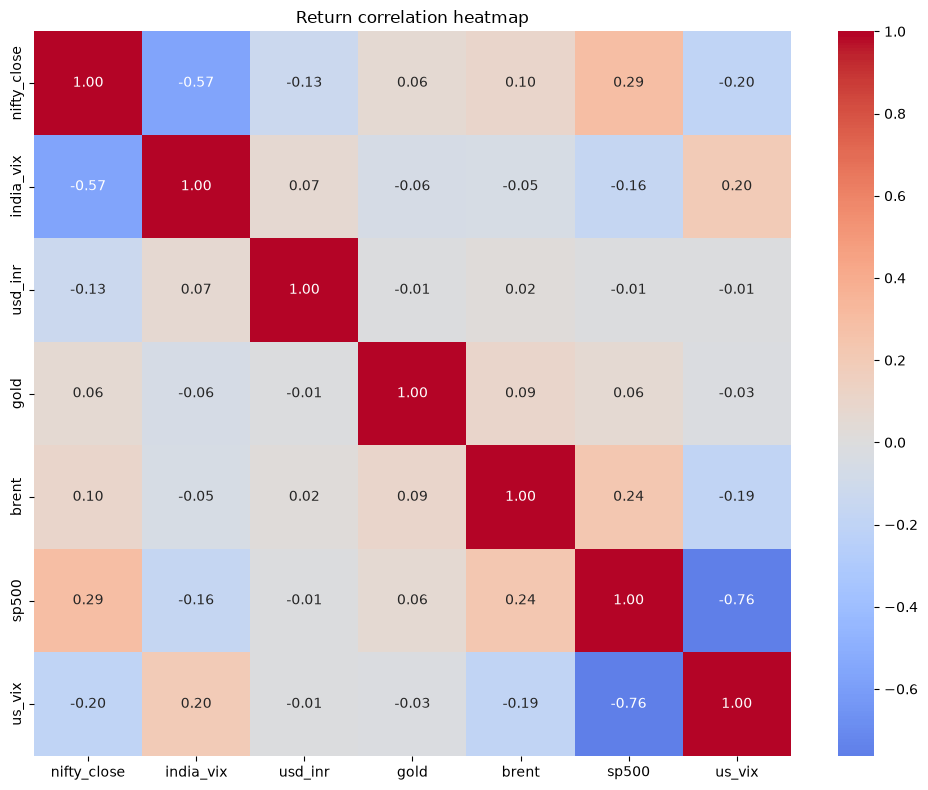

In [4]:
returns = log_returns(prices[['nifty_close', 'india_vix', 'usd_inr', 'gold', 'brent', 'sp500', 'us_vix']])
plt.figure(figsize=(10, 8))
sns.heatmap(returns.corr(), cmap='coolwarm', center=0, annot=True, fmt='.2f')
plt.title('Return correlation heatmap')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eda_return_correlation_heatmap.png', dpi=180, bbox_inches='tight')
plt.show()

## Required review
Inspect the generated charts, missingness, and stress-label frequency before changing thresholds. Record any transformations in the feature catalogue.